In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded=files.upload()

Saving archive.zip to archive.zip


In [3]:
import zipfile
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')
print("Unzip completed!")

Unzip completed!


In [4]:
import os
print(os.listdir())

['.config', 'archive.zip', 'retail_sales_dataset.csv', 'sample_data']


In [5]:
df = pd.read_csv('retail_sales_dataset.csv')
print(df.head())
print(df.shape)

    order_id  order_date customer_id customer_name   age gender   region  \
0  ORD-03903  2024-08-15   CUST32603   Aarav Mehta  39.0  Other  Central   
1  ORD-02198  2022-08-16   CUST07881  Sanjay Verma  28.0   Male     West   
2  ORD-01348  2021-08-29   CUST49296  Pooja Sharma  41.0  Other     West   
3  ORD-02076  2022-07-05   CUST05587   Priya Reddy  29.0  Other     West   
4  ORD-00287  2020-05-07   CUST58035   Ritu Sharma   9.0   Male  Central   

        city product_category product_name  ...  unit_price  discount_pct  \
0     Raipur        Groceries        Sugar  ...      346.32           NaN   
1     Mumbai           Beauty    Sunscreen  ...      858.66          0.08   
2      Surat        Furniture         Sofa  ...    25941.32          0.14   
3  Ahmedabad        Furniture    Bed Frame  ...    22071.92          0.17   
4     Nagpur        Groceries  Cooking Oil  ...      320.06          0.31   

   sales_amount    profit  shipping_cost  payment_method  \
0       4043.14    2

In [6]:

# FINAL FIX - check values
df = df.dropna(subset=['order_id'])

df['age'] = df['age'].fillna(df['age'].median())
df['quantity'] = df['quantity'].fillna(1)
df['discount_pct'] = df['discount_pct'].fillna(0)
df['customer_satisfaction'] = df['customer_satisfaction'].fillna(df['customer_satisfaction'].median())
df['days_to_ship'] = df['days_to_ship'].fillna(df['days_to_ship'].median())

# Migilina 30 rows
df = df.ffill()

print("Cleaning Completed!")
print(df.isnull().sum())

Cleaning Completed!
order_id                 0
order_date               0
customer_id              0
customer_name            0
age                      0
gender                   0
region                   0
city                     0
product_category         0
product_name             0
quantity                 0
unit_price               0
discount_pct             0
sales_amount             0
profit                   0
shipping_cost            0
payment_method           0
customer_satisfaction    0
return_flag              0
order_status             0
days_to_ship             0
dtype: int64


/tmp/ipykernel_1847/3092817648.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.ffill()


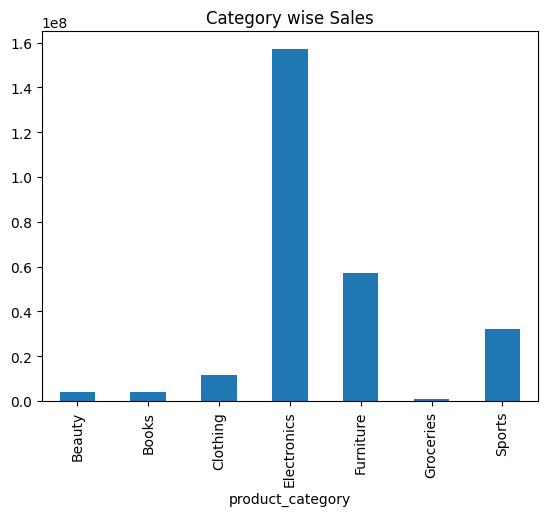

Graph generated!


In [7]:
import matplotlib.pyplot as plt

# Product category wise sales chuddam
df.groupby('product_category')['sales_amount'].sum().plot(kind='bar')
plt.title('Category wise Sales')
plt.show()

print("Graph generated!")

In [8]:
print("""
CONCLUSION - Task 1 Complete
1. Top Selling: Electronics & Sports
2. Lowest: Groceries
3. Insight: Focus on Electronics promotions
""")


CONCLUSION - Task 1 Complete
1. Top Selling: Electronics & Sports
2. Lowest: Groceries
3. Insight: Focus on Electronics promotions

